In [43]:
# Загрузка необходимых инструментов
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from typing import Dict, Tuple, List
import random
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus, value, PULP_CBC_CMD
import time
import math

In [44]:
# Решение задачи 0-1 ЦЛП на нахождение оптимальной сети
def solver_for_opt_network(network):
    
    n = network.n_players
    allowed_graph = network.allowed_graph
    neighbor_limits = network.neighbor_limits
    payoffs = network.payoffs
    model = LpProblem("BIP1", LpMaximize)

    # Создание переменных
    y = {}
    for (i, j) in allowed_graph:
        y[i, j] = LpVariable(f"y_{i}_{j}", cat=LpBinary)

    # Целевая функция
    model += lpSum(payoffs[(i, j)] * y[i, j] for (i, j) in allowed_graph)  
    
    # Ограничения
    for i in range(1, n+1):
        model += lpSum(y[min(i, j), max(i, j)] for j in range(1, n+1) if (min(i, j), max(i, j)) in allowed_graph) <= neighbor_limits[i]

    model.solve(PULP_CBC_CMD(msg=0, timeLimit=300))

    opt_edges = [] # Список оптимальных рёбер (для удобного перебора)
    opt_neighbors = {i: [] for i in range(1, n + 1)} # Словарь соседей (для быстрого доступа по вершине)
    
    for (i, j) in allowed_graph:
        if value(y[i ,j]) == 1:
            opt_edges.append((i , j))
            opt_neighbors[i].append(j)
            opt_neighbors[j].append(i)
            
    if model.status == 1:
        return {
            'opt_value': value(model.objective),
            'opt_edges': opt_edges,
            'neighbors_dict': dict(sorted(opt_neighbors.items()))
     }
    
    return "Error"

In [45]:
# Решение задачи 0-1 ЦЛП на нахождение модификации характеристической функции коалиции
def solver_for_v_2(network, coalition):
    
    allowed_graph = network.allowed_graph 
    neighbor_limits = network.neighbor_limits
    payoffs = network.payoffs 
    opt_neighbors = network.opt_neighbors
    bimatrix_games = network.bimatrix_games
    
    model = LpProblem("BIP2", LpMaximize)

    # Создание переменных
    z = {}
    for i in coalition:
        for j in set(opt_neighbors[i]).difference(coalition):
            z[i, j] = LpVariable(f"z_{i}_{j}", cat=LpBinary)
        for j in coalition:
            if (i, j) in allowed_graph:
                z[i, j] = LpVariable(f"z_{i}_{j}", cat=LpBinary)
                
    # Целевая функция
    model += lpSum(
        payoffs[(i, j)] * z[i, j] 
        for (i, j) in allowed_graph if {i, j}.issubset(coalition)
    ) + lpSum(
        network.max_min(bimatrix_games[(i,k)][0]) * z[i, k]
        for i in coalition 
        for k in set(opt_neighbors[i]).difference(coalition)
        if i < k
    ) + lpSum(
        network.max_min(bimatrix_games[(k,i)][1].T) * z[i, k]
        for i in coalition 
        for k in set(opt_neighbors[i]).difference(coalition)
        if i > k
    )

    # Ограничения 
    for i in coalition:
        model += (lpSum(z[i, j] for j in set(opt_neighbors[i]).difference(coalition))
                  + lpSum(z[min(i, j), max(i, j)] for j in coalition if (min(i, j), max(i, j)) in allowed_graph) ) <= neighbor_limits[i]
    
    model.solve(PULP_CBC_CMD(msg=1, timeLimit=300))

    edges_within_coalition = [] 
    v = 0
    for (i, j) in z:
        if z[i, j].varValue == 1:
            if i < j:
                if {i, j}.issubset(coalition):
                    v += payoffs[(i, j)]
                else:
                    v += network.max_min(bimatrix_games[(i,j)][0])
                edges_within_coalition += [(i, j)]
            else:
                v += network.max_min(bimatrix_games[(j, i)][1].T)
                edges_within_coalition += [(j, i)]

    edges_out_of_coalition = [(i, j) for (i, j) in network.opt_edges if i not in coalition and j not in coalition]
    all_edges = list(set(edges_out_of_coalition + edges_within_coalition))
    
    if model.status == 1:
         return {
             "new_edges": edges_within_coalition,
             "all_edges": all_edges,
             "v": v}

In [46]:
class CreateNetwork:
    def __init__(self, n: int, bimatrix_games: Dict[Tuple[int, int], Tuple[List[List[int]], List[List[int]]]], 
                 neighbor_limits: Dict[int, int], allowed_neighbors: Dict[int, List[int]]):
        self.n_players = n
        
        self.bimatrix_games = bimatrix_games

        self.neighbor_limits = neighbor_limits
        self.allowed_neighbors = allowed_neighbors

        self.allowed_graph = set()
 
        self.graph = nx.Graph()
        self.graph.add_nodes_from(range(1, self.n_players+1))
        self.params = optimized_graph_parameters(self.graph)

        self.payoffs = {}
        self.total_weight = 0

        self.precompute_weights()

        self.opt_value, self.opt_edges, self.opt_neighbors = solver_for_opt_network(self).values()
 
    def precompute_weights(self) -> None:
        for (i, j), (A, B) in self.bimatrix_games.items():
            if j in self.allowed_neighbors[i] and i in self.allowed_neighbors[j]:
                payoff = (A+B).max()
                self.payoffs[(i, j)] = payoff

                self.allowed_graph.add((i, j))

    def max_min(self, matrix) -> int:
        rows_min = []
        for s in range(len(matrix)):
            rows_min.append(min(matrix[s]))
        return max(rows_min)

    def find_v_1(self, coalition):
        v = 0
        if len(coalition) == 0:
            return 0
        for i in coalition:
            for j in self.opt_neighbors[i]:
                if j in coalition:
                    if i < j:
                        max_sum = np.max(self.bimatrix_games[(i, j)][0]+self.bimatrix_games[(i, j)][1])
                        v = v + float(max_sum)
                else:
                    if i < j:
                        v += self.max_min(self.bimatrix_games[(i,j)][0])
                    else:
                        v += self.max_min(self.bimatrix_games[(j, i)][1].T)
        return v
    
    def find_vector_shapley_1(self, n):
        shapley = np.zeros(n)
        players = range(1, n+1)
        all_coalitions = [comb for i in range(1, n + 1) for comb in combinations(players, i)]
        for coalition in all_coalitions:
            for i in coalition:
                s = len(coalition)
                coalition_without_i = tuple(x for x in coalition if x != i)
                shapley[i-1] += ( ( math.factorial(s - 1)*math.factorial(n - s) ) / math.factorial(n) ) * ( self.find_v_1(coalition) - self.find_v_1(coalition_without_i) )   
        return shapley

    def find_vector_shapley_2(self, n):
        shapley = np.zeros(n)
        players = range(1, n+1)
        all_coalitions = [comb for i in range(1, n + 1) for comb in combinations(players, i)]
        for coalition in all_coalitions:
            for i in coalition:
                s = len(coalition)
                coalition_without_i = tuple(x for x in coalition if x != i)
                shapley[i-1] += ( ( math.factorial(s - 1)*math.factorial(n - s) ) / math.factorial(n) ) * ( solver_for_v_2(self, coalition)["v"] - solver_for_v_2(self, coalition_without_i)["v"] )   
        return shapley

    def drawing(self, edges) -> None:

        self.graph.clear_edges()
        self.graph.add_edges_from(edges)

        pos = self.params['pos']
        
        plt.figure(figsize = self.params['figsize'])

        nx.draw_networkx_nodes(self.graph, pos, node_size = self.params['node_size'], node_color = 'lightblue', alpha = self.params['node_alpha'])
        
        nx.draw_networkx_labels(self.graph, pos, font_size = self.params['font_size'])
  
        nx.draw_networkx_edges(self.graph, pos, width = self.params['edge_width'], edge_color = 'gray', alpha = self.params['edge_alpha'])
        
        plt.axis("off")
        plt.show()


In [47]:
# Параметры рисунка графа для различного числа узлов
def optimized_graph_parameters(G, scale_multiplier=1.5):
    n = G.number_of_nodes()
    
    if n <= 6:
        k_val = 0.3
        iterations = 15
        scale = 0.8
        figsize = (7, 7)
        node_size = 800
        edge_width = 3.0
        font_size = 20
        node_alpha = 0.9
        edge_alpha = 0.8
    elif n <= 15:
        k_val = 0.6
        iterations = 25
        scale = 1.0
        figsize = (10, 8)
        node_size = 600
        edge_width = 1.5
        font_size = 11
        node_alpha = 0.85
        edge_alpha = 0.7
    elif n <= 30:
        k_val = 1.5          
        iterations = 60     
        scale = 1.8          
        figsize = (14, 12)   
        node_size = 400      
        edge_width = 1.0    
        font_size = 13       
        node_alpha = 0.8    
        edge_alpha = 0.6
    elif n <= 60:
        k_val = 1.2
        iterations = 50
        scale = 1.6
        figsize = (14, 12)
        node_size = 300
        edge_width = 1.0
        font_size = 9
        node_alpha = 0.75
        edge_alpha = 0.5
    elif n <= 90:
        k_val = 1.4
        iterations = 70
        scale = 1.8
        figsize = (16, 14)
        node_size = 250
        edge_width = 0.8
        font_size = 8
        node_alpha = 0.7
        edge_alpha = 0.45
    elif n <= 120:
        k_val = 1.6
        iterations = 90
        scale = 2.0
        figsize = (18, 16)
        node_size = 450
        edge_width = 0.7
        font_size = 12
        node_alpha = 0.65
        edge_alpha = 0.4
    elif n <= 160:
        k_val = 1.8
        iterations = 110
        scale = 2.2
        figsize = (20, 18)
        node_size = 150
        edge_width = 0.6
        font_size = 6
        node_alpha = 0.6
        edge_alpha = 0.35
    elif n <= 200:
        k_val = 2.0
        iterations = 130
        scale = 2.4
        figsize = (22, 20)
        node_size = 120
        edge_width = 0.5
        font_size = 5
        node_alpha = 0.55
        edge_alpha = 0.3
    else:
        k_val = 2.5
        iterations = 150
        scale = 2.8
        figsize = (24, 22)
        node_size = 100
        edge_width = 0.4
        font_size = 4
        node_alpha = 0.5
        edge_alpha = 0.25
        
    pos = nx.spring_layout(G,
        k=k_val * scale_multiplier,
        iterations=iterations,
        threshold=1e-4,
        scale=scale * scale_multiplier,
        seed=42
    )

    return {
        'pos': pos,
        'figsize': figsize,
        'node_size': node_size,
        'edge_width': edge_width,
        'font_size': font_size,
        'node_alpha': node_alpha,
        'edge_alpha': edge_alpha
    }

In [48]:
# Генерация матриц выигрышей 
def сreate_bimatrix_games(n, m_strategy, k_strategy, lower_limit: int, upper_limit: int):
    pairs = list(combinations(range(1, n+1), 2))
    bimatrix_games = {}
        
    for pair in pairs:
        key = pair
        payoff1 = np.random.randint(lower_limit, upper_limit, (m_strategy, k_strategy))
        payoff2 = np.random.randint(lower_limit, upper_limit, (m_strategy, k_strategy))
        bimatrix_games[key] = (payoff1, payoff2)
    return bimatrix_games

In [49]:
# Генерация ограничений
def сreate_two_constraints(n):
    allowed_neighbors={}
    neighbor_limits={} 
    
    for key in range(1, n + 1):
        possible_values = [i for i in range(1, n + 1) if i != key]
        list_size = random.randint(0, n - 1)
        random_values = random.sample(possible_values, list_size)
        random_values.sort()
        allowed_neighbors[key] = random_values

        neighbor_limits[key]=random.randint(0, n - 1)
    return allowed_neighbors, neighbor_limits   

In [52]:
# Красивый вывод биматричных игр
def print_dict_matrices_with_names(dictionary, m, k) -> None:
    for key, matrices in dictionary.items():
    
        name1 = f"A{key}"
        name2 = f"A{key[::-1]}"
        
        for i in range(m):
            if i == m // 2:
                print(f"{name1} = ", end='')
                print(*matrices[0][i], end='  ')
                print(f"{name2} = ", end='')
                print(*matrices[1][i])
            else:
                print(' '*(len(name1)+2), *matrices[0][i], end='  ')                            
                print(' '*(len(name2)+2), *matrices[1][i])
                
        print()

Рассмотрим игру с n = 5, m = 3, k = 2.

Множества допустимых игроков:
{1: [2, 3, 4, 5], 2: [1, 3, 4, 5], 3: [2], 4: [3, 5], 5: [2, 3, 4]} 

Максимальные количества связей:
{1: 2, 2: 0, 3: 0, 4: 2, 5: 4} 

Биматричные игры:
          7 2            6 3
A(1, 2) = 5 6  A(2, 1) = 5 6
          4 1            2 3

          8 8            9 4
A(1, 3) = 4 5  A(3, 1) = 4 8
          7 6            6 9

          4 5            6 2
A(1, 4) = 7 7  A(4, 1) = 4 2
          9 7            7 4

          5 8            4 4
A(1, 5) = 1 1  A(5, 1) = 4 5
          1 2            4 7

          5 6            8 8
A(2, 3) = 6 3  A(3, 2) = 1 3
          5 4            9 4

          7 5            5 8
A(2, 4) = 9 2  A(4, 2) = 4 8
          3 1            2 9

          3 9            8 6
A(2, 5) = 9 1  A(5, 2) = 6 6
          7 9            5 7

          9 3            6 2
A(3, 4) = 6 7  A(4, 3) = 2 5
          7 3            3 5

          8 2            7 6
A(3, 5) = 9 3  A(5, 3) = 8 9
          9 2  

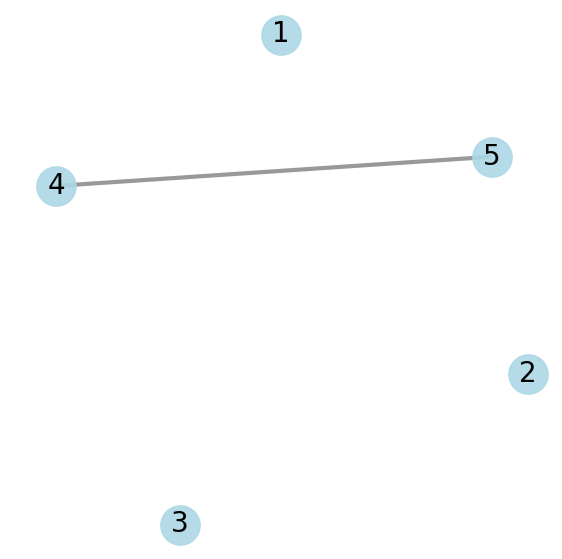

v(N) = 14.0 

Модификация сети при вычислении v^({1, 2, 3, 4, 5})
v({1, 2, 3, 4, 5}) = 14.0, v^({1, 2, 3, 4, 5}) = 14

Модифицированный граф:


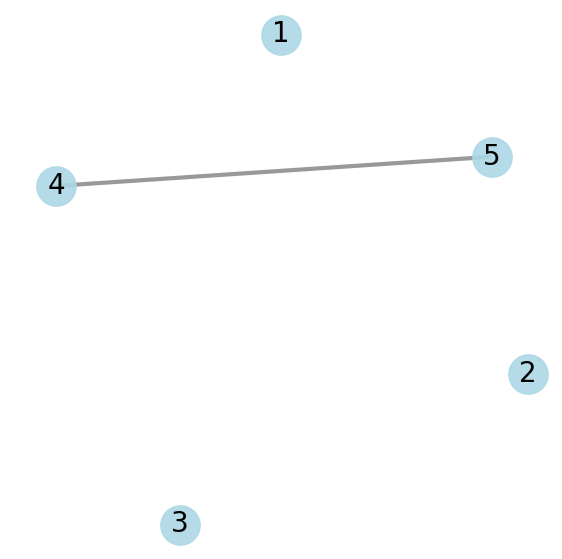

Векторы Шепли:
Sh(v) = [0.  0.  0.  6.5 7.5]


KeyboardInterrupt: 

In [69]:
def main():

    n = 5
    m = 3
    k = 2
    bimatrix_games = сreate_bimatrix_games(n, m, k, 1, 10)
    allowed_neighbors, neighbor_limits = сreate_two_constraints(n)

    print(f'Рассмотрим игру с n = {n}, m = {m}, k = {k}.')
    print()

    print("Множества допустимых игроков:")
    print(allowed_neighbors, "\n")

    print("Максимальные количества связей:")
    print(neighbor_limits, "\n")

    print("Биматричные игры:")
    print_dict_matrices_with_names(bimatrix_games, m, k)


    network = CreateNetwork(n, bimatrix_games, neighbor_limits, allowed_neighbors)
    
    print("Граф оптимальной сети:")
    network.drawing(network.opt_edges)
    print(f"v(N) = {network.opt_value} \n")

    size = random.randint(0, n)
    if size == 0:
        coalition = set()
    else:
        coalition = set(random.sample(range(1, n+1), size))
    coalition_edges, all_edges, v = solver_for_v_2(network, coalition).values()
    
    print(f"Модификация сети при вычислении v^({coalition})")
    print(f"v({coalition}) = {network.find_v_1(coalition)}, v^({coalition}) = {v}")
    print()
    print("Модифицированный граф:")
    network.drawing(all_edges)

    print("Векторы Шепли:")
    print(f'Sh(v) = {network.find_vector_shapley_1(n)}')
    print(f'Sh(v^) = {network.find_vector_shapley_2(n)}')

if __name__ == "__main__":
    start_time = time.time()
    
    main()
         
    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Программа работала: {execution_time:.4f} секунд") 